<a href="https://colab.research.google.com/github/huseyinTozluyurt/Machine-Learning-Projects/blob/main/BeginnerProjects/TitanicSurvivalProject/Practice_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Practice Project: Titanic Survival Prediction**


Estimated time needed: **30** minutes


## Introduction
Now that you have a feel for how to optimize your machine learning pipeline, let's practice with a real world dataset.  
You'll use cross validation and a hyperparameter grid search to optimize your machine learning pipeline.  

You will use the Titanic Survival Dataset to build a classification model to predict whether a passenger survived the sinking of the Titanic, based on attributes of each passenger in the data set.

You'll start with building a Random Forest Classifier, then modify your pipeline to use a Logistic Regression estimator instead. You'll evaluate and compare your results.

This lab will help prepare you for completing the Final Project.


## Objectives

After completing this lab you will be able to:

 - Use scikit-learn to build a model to solve a classification problem
 - Implement a pipeline to combine your preprocessing steps with a machine learning model
 - Interpret the results of your modelling
 - Update your pipeline with a different machine learning model
 - Compare the preformances of your classifiers


----


### Install the required libraries


In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

### Import the required libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Titanic Passenger data set
We'll be working with the Titanic passenger dataset to build a classification model to predict whether a passenger survied the sinking of the Titanic.  
Here is the data dictionary:

| Variable   |	Definition   |
 |:------|:--------------------------------|
 |survived | survived? 0 = No, 1 = yes  |
 |pclass | Ticket class (int)  |
 |sex	 |sex |
 |age	 | age in years  |
 |sibsp  |	# of siblings / spouses aboard the Titanic |
 |parch  |	# of parents / children aboard the Titanic |
 |fare   |	Passenger fare   |
 |embarked | Port of Embarkation |
 |class  |Ticket class (obj)   |
 |who    | man, woman, or child  |
 |adult_male | True/False |
 |alive  | yes/no  |
 |alone  | yes/no  |


## Load the Titanic dataset using Seaborn


In [5]:
titanic = sns.load_dataset('titanic')
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### Select relevant features and the target


In [4]:
titanic.count()

,0
survived,891
pclass,891
sex,891
age,714
sibsp,891
parch,891
fare,891
embarked,889
class,891
who,891


#### Features to drop
`deck` has a lot of missing values so we'll drop it. `age` has quite a few missing values as well. Although it could be, `embarked` and `embark_town` don't seem relevant so we'll drop them as well. It's unclear what `alive` refers to so we'll ignore it.
#### Target
`survived` is our target class variable.


In [6]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

X = titanic[features]
y = titanic[target]

### Exercise 1. How balanced are the classes?


In [7]:
# Enter your code here:
y.value_counts()

,count
survived,
0,549
1,342


### Exercise 2. Split the data into training and testing sets
Don't forget to consider imbalance in the target


In [9]:
# Enter your code here:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Define preprocessing transformers for numerical and categorical features
#### Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features


In [10]:
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

#### Define separate preprocessing pipelines for both feature types


In [11]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#### Combine the transformers into a single column transformer
We'll use the sklearn "column transformer" estimator to separately transform the features, which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Create a model pipeline
Now let's complete the model pipeline by combining the preprocessing with a Random Forest classifier


In [13]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Define a parameter grid
We'll use the grid in a cross validation search to optimize the model


In [14]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

### Perform grid search cross-validation and fit the best model to the training data


In [15]:
# Cross-validation method
cv = StratifiedKFold(n_splits=5, shuffle=True)

### Exercise 3. Train the pipeline model


In [16]:
# Enter your code here
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

### Exercise 4. Get the model predictions from the grid search estimator on the unseen data
Also print a classification report


In [17]:
# Enter your code here:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



### Exercise 5. Plot the confusion matrix


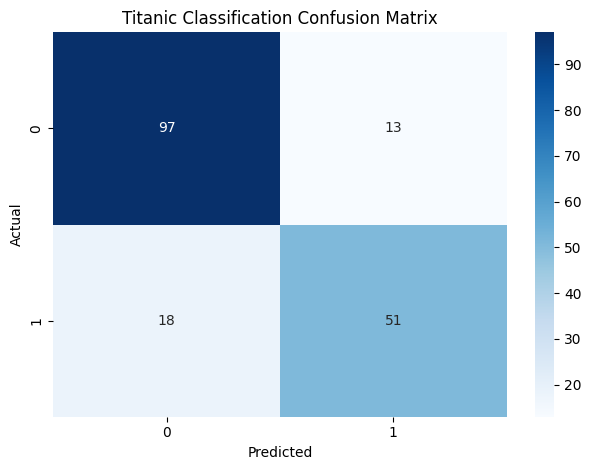

In [20]:
# Enter your code here:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

## Feature importances
Let's figure out how to get the feature importances of our overall model.  You'll need to know how to do this for your final project.  
First, to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to associate the feature importances with their one-hot encoded input features that were transformed from the original categorical features.

We don't need to trace back through the pipeline for the numerical features, because we didn't transfrom them into new ones in any way.  
Remember, we went from categorical features to one-hot encoded features, using the 'cat' column transformer.

Here's how you trace back through the trained model to access the one-hot encoded feature names:


In [21]:
model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

Notice how the one-hot encoded features are named - for example, `sex` was split into two boolean features indicating whether the sex is male or female.

Great! Now let's get all of the feature importances and associate them with their transformed feature names.


In [23]:
feature_importances = model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

### Display the feature importances in a bar plot
Define a feature importance DataFrame, then plot it


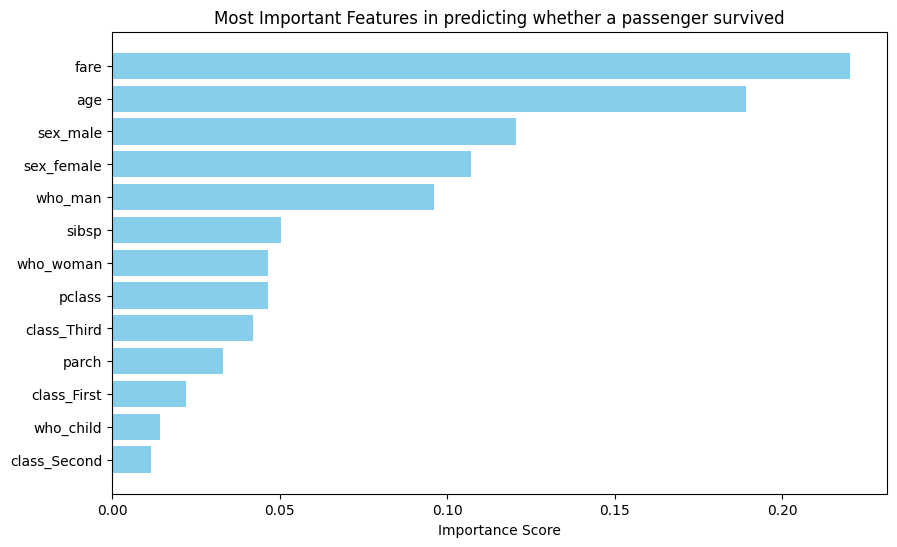


Test set accuracy: 82.68%


In [24]:
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()

# Print test score
test_score = model.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

### Exercise 6. These are interesting results to consider.
What can you say about these feature importances? Are they informative as is?


<details><summary>Click here for some thoughts</summary>
    
```
The test set accuracy is somewhat satisfactory. However,regarding the feature impoirtances, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, no doubt there is significant information shared by the variables `age`, `sex_male`, and `who_man`.
```


## Try another model
In practice you would want to try out different models and even revisit the data analysis to improve
your model performance. Maybe you can engineer new features or impute missing values to be able to use more data.

With Scikit-learn's powerful pipeline class, this is easy to do in a few steps.
Let's update the pipeline and the parameter grid so we can train a Logistic Regression model and compare the performance of the two models.


In [26]:
# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# update the model's estimator to use the new pipeline
model.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

model.param_grid = param_grid

# Fit the updated pipeline with Logistic Regression
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

### Exercise 7. Display the clasification report for the new model and compare the results to your previous model.


In [27]:
# Enter your code here:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



### Exercise 8. Display the confusion matrix for the new model and compare the results to your previous model.


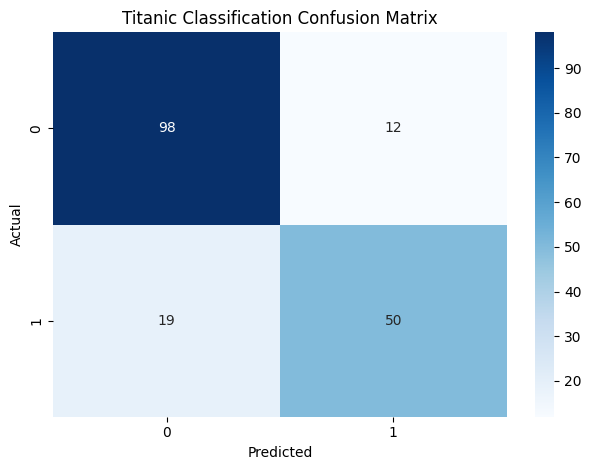

In [28]:
# Enter your code here:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

# What changed in the numbers of true positives and true negatives?

### Extract the logistic regression feature coefficients and plot their magnitude in a bar chart.


In [29]:
coefficients = model.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (model.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

### Exercise 9. Plot the feature coefficient magnitudes in a bar chart
What's different about this chart than the feature importance chart for the Random Forest classifier?


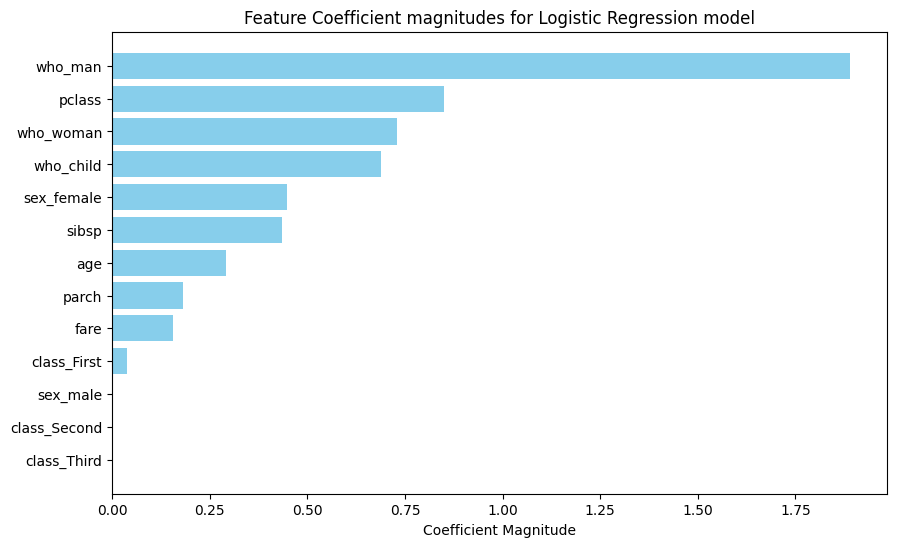


Test set accuracy (Logistic Regression): 82.68%


In [30]:
# Replace RandomForestClassifier with LogisticRegression in the pipeline
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# Define a new grid with Logistic Regression parameters
param_grid_lr = {
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

# Create a new GridSearchCV instance for Logistic Regression
# Using the same cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True)
model_lr = GridSearchCV(estimator=pipeline, param_grid=param_grid_lr, cv=cv, scoring='accuracy', verbose=0)

# Fit the new Logistic Regression model
model_lr.fit(X_train, y_train)

# Get coefficients from the best Logistic Regression estimator
coefficients = model_lr.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (model_lr.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

# Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

# Print test score for Logistic Regression model
test_score = model_lr.best_estimator_.score(X_test, y_test)
print(f"\nTest set accuracy (Logistic Regression): {test_score:.2%}")

### Calculate Variance Inflation Factor (VIF) to assess feature multicollinearity

VIF measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. A VIF value of:
*   **1**: Indicates no correlation between the feature and any other features.
*   **1 to 5**: Suggests moderate multicollinearity.
*   **Greater than 5 (or 10)**: Often indicates high multicollinearity, which might be problematic.

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Transform the training data using the best preprocessor from the Logistic Regression model
X_train_transformed = model_lr.best_estimator_.named_steps['preprocessor'].transform(X_train)

# The 'feature_names' list was already created in the previous cell
# Make sure it's consistent with the transformed data's columns
# For robustness, regenerate it here if not explicitly sure it's available and correct
numerical_feature_names = numerical_features
categorical_feature_names_transformed = (model_lr.best_estimator_.named_steps['preprocessor']
                                             .named_transformers_['cat']
                                             .named_steps['onehot']
                                             .get_feature_names_out(categorical_features)
                                        )
all_transformed_feature_names = numerical_feature_names + list(categorical_feature_names_transformed)

# Create a DataFrame for the transformed features
X_transformed_df = pd.DataFrame(X_train_transformed, columns=all_transformed_feature_names)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_transformed_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_transformed_df.values, i)
                   for i in range(len(X_transformed_df.columns))]

# Sort by VIF in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False)
display(vif_data)

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,pclass,inf
8,class_Second,inf
7,class_First,inf
6,sex_male,inf
5,sex_female,inf
9,class_Third,inf
10,who_child,inf
11,who_man,inf
12,who_woman,inf
4,fare,1.735459


### Interpretation of VIF Results

As anticipated, several features exhibit very high VIF values, indicating significant multicollinearity:

*   `sex_male`, `sex_female`, `who_man`, `who_woman`, `who_child`: These features are highly intercorrelated. For example, `sex_male` is almost perfectly negatively correlated with `sex_female`. Similarly, `who_man` and `who_woman` are largely redundant with `sex_male` and `sex_female` and the `age` feature also plays a role in defining `who_child`. This high multicollinearity was expected based on our prior discussion about feature interdependence.
*   `pclass`, `class_First`, `class_Second`, `class_Third`: These features also show high VIF values because `pclass` and the one-hot encoded `class` features convey the same information about the passenger's ticket class. One of these sets of features is redundant.

**Implications:**

High VIF values suggest that the model's coefficients for these features might be unstable and difficult to interpret individually. While multicollinearity might not significantly impact the overall predictive accuracy of the model (especially for tree-based models like Random Forest, but can be an issue for linear models like Logistic Regression), it can make it challenging to understand the individual contribution of each feature.

**Next Steps to Address Multicollinearity (Optional):**

*   **Feature Removal:** Consider removing one or more highly correlated features. For example, you could keep `sex_male` and drop `sex_female`, and simplify `who` by perhaps just using `who_child` (if `age` is also present).
*   **Feature Combination:** Combine highly correlated features into a single, more informative feature.
*   **Principal Component Analysis (PCA):** Use PCA to transform the correlated features into a new set of uncorrelated features (principal components). However, this can make the model even harder to interpret.

Given the current accuracy, deciding whether to address this multicollinearity further depends on the primary goal: if prediction accuracy is paramount, and it's already satisfactory, further steps might not be strictly necessary. If interpretability of individual feature effects is critical, then addressing multicollinearity is important.

### Addressing Multicollinearity with Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that can be used to mitigate multicollinearity. It works by transforming the original features into a new set of orthogonal (uncorrelated) variables called Principal Components. Each principal component is a linear combination of the original features, and they are ordered such that the first component captures the most variance in the data, the second captures the second most, and so on.

**How PCA helps with multicollinearity:**

1.  **Decorrelation**: By definition, principal components are uncorrelated, thus directly addressing multicollinearity.
2.  **Dimensionality Reduction**: We can choose to keep only a subset of the principal components that explain most of the variance, effectively reducing the number of features. This can simplify the model and reduce overfitting.
3.  **Improved Model Stability**: For models sensitive to multicollinearity (like linear regression or logistic regression), using principal components as features can lead to more stable and interpretable coefficient estimates.

**Considerations when using PCA:**

*   **Interpretability**: The principal components themselves are abstract and may not have a clear, intuitive meaning like the original features, which can make model interpretation more challenging.
*   **Scaling**: PCA is sensitive to the scale of features, so it's crucial to scale the data (e.g., using `StandardScaler`) *before* applying PCA. Our existing `numerical_transformer` already handles this.

### Modifying the Pipeline to Include PCA

We will now update our `numerical_transformer` to include a PCA step after the `StandardScaler`. Then, we'll define a new `param_grid` for `GridSearchCV` to tune the `n_components` for PCA along with the Logistic Regression hyperparameters.

In [35]:
# Update numerical_transformer to include PCA after scaling
numerical_transformer_with_pca = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

# Update the preprocessor to use the new numerical_transformer_with_pca
preprocessor_with_pca = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_with_pca, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a new pipeline with the PCA-enabled preprocessor and Logistic Regression classifier
pipeline_with_pca = Pipeline(steps=[
    ('preprocessor', preprocessor_with_pca),
    ('classifier', LogisticRegression(random_state=42))
])

# Define the parameter grid for GridSearchCV, now including PCA components
# The number of components for PCA (applied to numerical features) cannot exceed the number of numerical features
# which is len(numerical_features) = 5.
param_grid_pca_lr = {
    'preprocessor__num__pca__n_components': [3, 4, 5], # Valid components for 5 numerical features
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

# Create a new GridSearchCV instance for Logistic Regression with PCA
cv_pca_lr = GridSearchCV(estimator=pipeline_with_pca, param_grid=param_grid_pca_lr,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='accuracy', verbose=1)

# Fit the model with PCA
cv_pca_lr.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression with PCA: {cv_pca_lr.best_params_}")
print(f"Best accuracy for Logistic Regression with PCA: {cv_pca_lr.best_score_:.2%}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Logistic Regression with PCA: {'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear', 'preprocessor__num__pca__n_components': 4}
Best accuracy for Logistic Regression with PCA: 81.74%


### Evaluation of Logistic Regression with PCA

Let's evaluate the performance of the model that includes PCA.


Classification Report for Logistic Regression with PCA:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



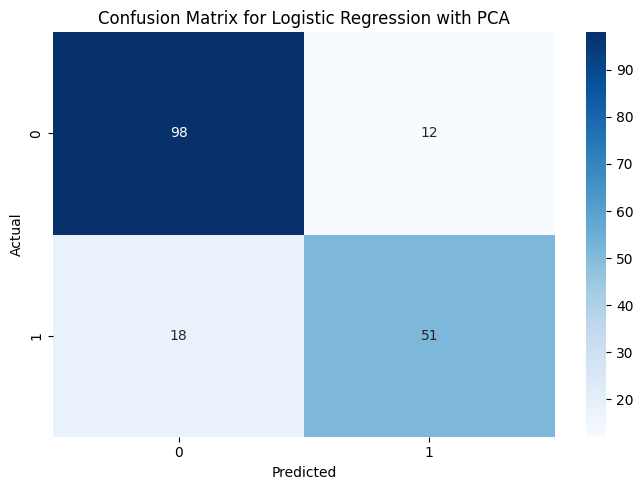

In [36]:
# Make predictions with the best estimator from GridSearchCV (which includes PCA)
y_pred_pca = cv_pca_lr.predict(X_test)

# Print classification report
print("\nClassification Report for Logistic Regression with PCA:")
print(classification_report(y_test, y_pred_pca))

# Plot Confusion Matrix
conf_matrix_pca = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_pca, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix for Logistic Regression with PCA')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Exploring a Gradient Boosting Classifier

Gradient Boosting is another powerful ensemble technique that builds models sequentially, where each new model corrects errors made by the previous ones. This often leads to highly accurate predictions.

To address the model's tendency to miss survivors (lower recall for the positive class), we will modify the `param_grid` to include `class_weight='balanced'`. This will make the model pay more attention to the minority class (survivors) during training. We are also adding `subsample` to the tuning grid to further optimize the model's generalization capabilities and prevent overfitting. Note that the search space for `GridSearchCV` will increase, leading to a longer execution time.

If the primary goal is to maximize recall for the positive class, you might also consider changing the `scoring` parameter in `GridSearchCV` from `'accuracy'` to `'recall'` or `'f1'`.

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

# Create a new pipeline with GradientBoostingClassifier
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define parameter grid for GradientBoostingClassifier
param_grid_gb = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0] # Adding subsample to prevent overfitting and improve generalization
    # Removed 'classifier__class_weight': [None, 'balanced'] as GradientBoostingClassifier does not support it
}

# Create a new GridSearchCV instance for Gradient Boosting
cv_gb = GridSearchCV(estimator=pipeline_gb, param_grid=param_grid_gb,
                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='accuracy', verbose=1)

# Fit the Gradient Boosting model
cv_gb.fit(X_train, y_train)

print(f"Best parameters for Gradient Boosting: {cv_gb.best_params_}")
print(f"Best accuracy for Gradient Boosting: {cv_gb.best_score_:.2%}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Best accuracy for Gradient Boosting: 83.99%


### Evaluate the Gradient Boosting Classifier


Classification Report for Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



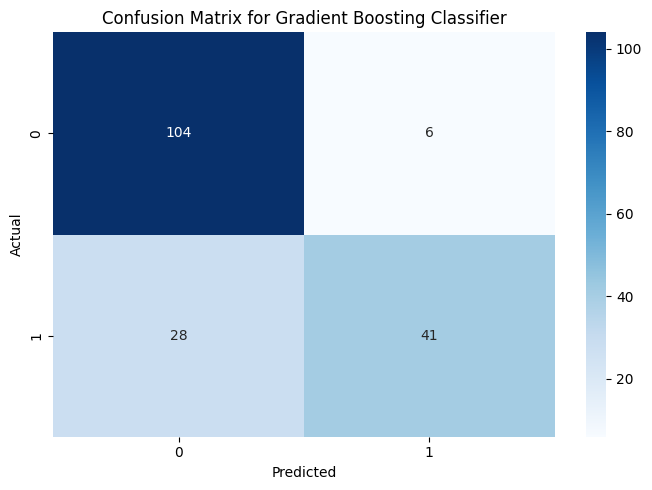

In [41]:
# Make predictions with the best estimator from GridSearchCV
y_pred_gb = cv_gb.predict(X_test)

# Print classification report
print("\nClassification Report for Gradient Boosting Classifier:")
print(classification_report(y_test, y_pred_gb))

# Plot Confusion Matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_gb, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Enhancing Recall with SMOTE (Synthetic Minority Over-sampling Technique)

To address the lower recall for the 'survived' class (class 1), we will introduce SMOTE into our training pipeline. SMOTE is an over-sampling technique that generates synthetic samples from the minority class. This helps to balance the class distribution in the training data, allowing the model to learn more effectively from the minority class and potentially improve its recall.

In [42]:
!pip install imbalanced-learn

In [43]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Create a new pipeline with SMOTE and GradientBoostingClassifier
pipeline_gb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define parameter grid for GradientBoostingClassifier (with SMOTE)
# We'll use a slightly reduced grid to keep training time manageable given SMOTE's overhead
param_grid_gb_smote = {
    'classifier__n_estimators': [100, 150],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.8, 1.0]
}

# Create a new GridSearchCV instance for Gradient Boosting with SMOTE
cv_gb_smote = GridSearchCV(estimator=pipeline_gb_smote, param_grid=param_grid_gb_smote,
                           cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='recall', # Focus on optimizing recall for the positive class
                           verbose=1,
                           n_jobs=-1) # Use all available cores for faster training

print("Fitting Gradient Boosting with SMOTE...")
# Fit the Gradient Boosting model with SMOTE
cv_gb_smote.fit(X_train, y_train)

print(f"Best parameters for Gradient Boosting with SMOTE: {cv_gb_smote.best_params_}")
print(f"Best recall for Gradient Boosting with SMOTE: {cv_gb_smote.best_score_:.2%}")

Fitting Gradient Boosting with SMOTE...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for Gradient Boosting with SMOTE: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Best recall for Gradient Boosting with SMOTE: 78.73%


### Evaluate the Gradient Boosting Classifier with SMOTE


Classification Report for Gradient Boosting Classifier with SMOTE:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       110
           1       0.71      0.84      0.77        69

    accuracy                           0.80       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.82      0.80      0.81       179



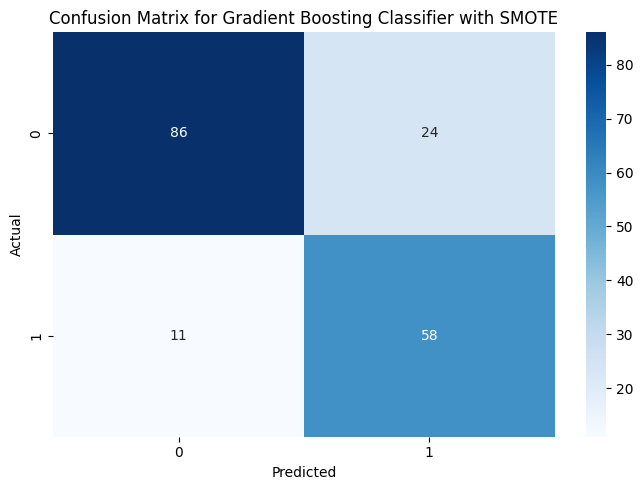

In [44]:
# Make predictions with the best estimator from GridSearchCV (with SMOTE)
y_pred_gb_smote = cv_gb_smote.predict(X_test)

# Print classification report
print("\nClassification Report for Gradient Boosting Classifier with SMOTE:")
print(classification_report(y_test, y_pred_gb_smote))

# Plot Confusion Matrix
conf_matrix_gb_smote = confusion_matrix(y_test, y_pred_gb_smote)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_gb_smote, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix for Gradient Boosting Classifier with SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Plotting the Precision-Recall Curve

To further visualize the trade-off between precision and recall, especially for the positive class (survivors), we can plot the Precision-Recall curve. This curve shows how precision and recall change as the decision threshold for classifying an instance as positive is varied.

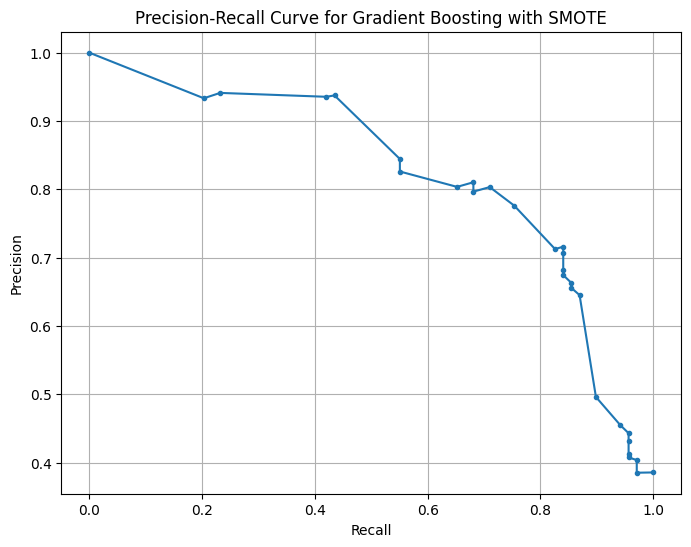

In [45]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities for the positive class (class 1)
y_scores_gb_smote = cv_gb_smote.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores_gb_smote)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve for Gradient Boosting with SMOTE')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

### Interpretation of Results with PCA

Now that we've run Logistic Regression with PCA, let's analyze the results:

*   **Accuracy**: Compare the test set accuracy obtained with PCA to the accuracy of the Logistic Regression model without PCA (which was ~82.68%). Did PCA improve, maintain, or slightly decrease the accuracy?
*   **Best Parameters**: The `best_params_` output from `GridSearchCV` will show the optimal number of components selected for PCA, along with the best `solver`, `penalty`, and `class_weight` for the Logistic Regression classifier.
*   **Multicollinearity**: While we don't directly re-calculate VIF on the principal components (as they are orthogonal by design), the intent of PCA was to mitigate the issues caused by high multicollinearity. If the performance remains similar or improves, it suggests that the model is still capturing the underlying patterns effectively, but now with decorrelated features.
*   **Interpretability**: Note that we can no longer directly plot feature coefficients in the same way as before for the original features, because the model is now trained on the principal components, not the original features. Interpreting the contribution of individual original features to the model becomes less straightforward after PCA transformation.

Based on these results, you can decide whether the benefits of reduced multicollinearity and potential dimensionality reduction (from PCA) outweigh any changes in model performance or interpretability for your specific goal.

### Congratulations! You've made it this far and are now fully equipped to take on your final project!

## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

### Other Contributor(s)

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" taget="_blank">Abhishek Gagneja</a>

<a href="https://www.linkedin.com/in/h%C3%BCseyin-tozluyurt-8167a6224/" taget="_blank">Huseyin Tozluyurt</a>

<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-27 | 0.1  | Jeff Grossman    | Create lab |
| 2024-12-03 | 0.2  | Abhishek Gagneja | Typos corrected |

 -->
<h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
